In [1]:
import warnings
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf

import keras
from keras.models import Sequential
from keras.utils import to_categorical
from tensorflow.keras.utils import plot_model
from keras.optimizers import Adam
from keras.layers import Dense, Activation, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization, ZeroPadding2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

warnings.filterwarnings("ignore")

In [2]:
import torch
# Select GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [3]:
IMAGE_DIR = r".\images"

CSV_PATH = r".\images.csv"


In [4]:
df = pd.read_csv(CSV_PATH)

print(df.shape)

print(df.columns)

df.head()


(5403, 4)
Index(['image', 'sender_id', 'label', 'kids'], dtype='str')


,image,sender_id,label,kids
0,4285fab0-751a-4b74-8e9b-43af05deee22,124,Not sure,False
1,ea7b6656-3f84-4eb3-9099-23e623fc1018,148,T-Shirt,False
2,00627a3f-0477-401c-95eb-92642cbe078d,94,Not sure,False
3,ea2ffd4d-9b25-4ca8-9dc2-bd27f1cc59fa,43,T-Shirt,False
4,3b86d877-2b9e-4c8b-a6a2-1d87513309d0,189,Shoes,False


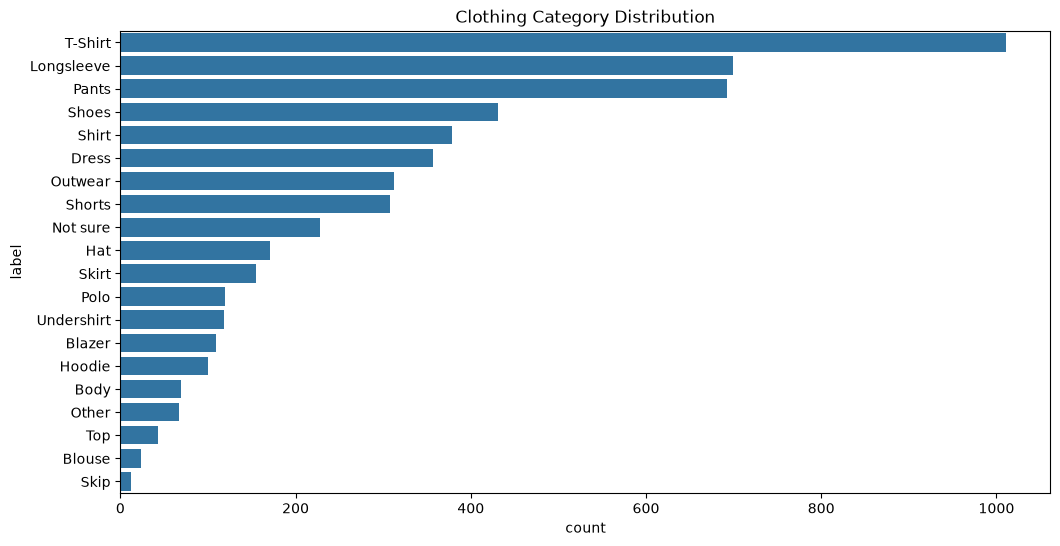

In [5]:
plt.figure(figsize=(12,6))

sns.countplot(
    y=df["label"],
    order=df["label"].value_counts().index
)

plt.title("Clothing Category Distribution")

plt.show()

In [6]:
# cleaning

labels_to_remove = ['Skip', 'Not sure', 'Other']
df = df[~df['label'].isin(labels_to_remove)]

class_counts = df["label"].value_counts()

valid_classes = class_counts[
    class_counts >= 100
].index

df = df[
    df["label"].isin(valid_classes)
]


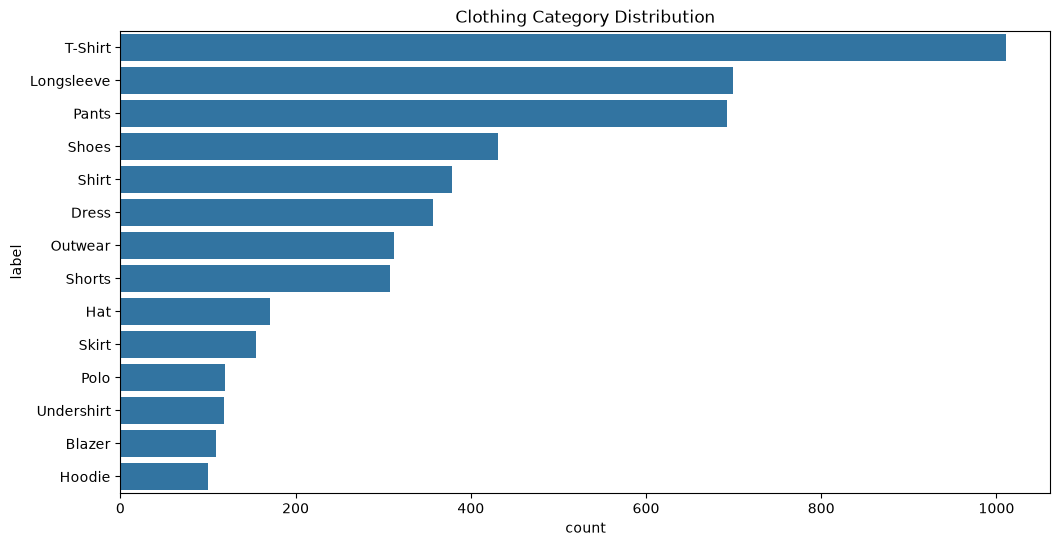

In [7]:
plt.figure(figsize=(12,6))

sns.countplot(
    y=df["label"],
    order=df["label"].value_counts().index
)

plt.title("Clothing Category Distribution")

plt.show()

In [7]:
# Create image path
df['image_path'] = df['image'].apply(lambda x: f"{IMAGE_DIR}/{x}.jpg")
print(df.head())



                                  image  sender_id    label   kids  \
1  ea7b6656-3f84-4eb3-9099-23e623fc1018        148  T-Shirt  False   
3  ea2ffd4d-9b25-4ca8-9dc2-bd27f1cc59fa         43  T-Shirt  False   
4  3b86d877-2b9e-4c8b-a6a2-1d87513309d0        189    Shoes  False   
5  5d3a1404-697f-479f-9090-c1ecd0413d27        138   Shorts  False   
6  b0c03127-9dfb-4573-8934-1958396937bf        138    Shirt  False   

                                          image_path  
1  .\images/ea7b6656-3f84-4eb3-9099-23e623fc1018.jpg  
3  .\images/ea2ffd4d-9b25-4ca8-9dc2-bd27f1cc59fa.jpg  
4  .\images/3b86d877-2b9e-4c8b-a6a2-1d87513309d0.jpg  
5  .\images/5d3a1404-697f-479f-9090-c1ecd0413d27.jpg  
6  .\images/b0c03127-9dfb-4573-8934-1958396937bf.jpg  


In [8]:
import cv2
from tqdm import tqdm

IMG_SIZE = 128

images = []
labels = []

# Shuffling dataframe to avoid bias
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

for _, row in tqdm(df_shuffled.iterrows(), total=len(df_shuffled)):
    img_path = row['image_path']
    label = row['label']

    img = cv2.imread(img_path)

    # Skipping corrupted/missing images
    if img is None:
        continue

    try:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img)
        labels.append(label)

    except:
        continue

print("Total images loaded:", len(images))

100%|██████████| 4961/4961 [02:21<00:00, 34.95it/s]

Total images loaded: 4961


In [9]:
import numpy as np

X = np.array(images)
y = np.array(labels)

# Normalize
X = X / 255.0

print(X.shape)
print(len(y))

(4961, 128, 128, 3)
4961


In [10]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# One-hot encoding
y_categorical = to_categorical(y_encoded)

print("Classes:", le.classes_)

Classes: ['Blazer' 'Dress' 'Hat' 'Hoodie' 'Longsleeve' 'Outwear' 'Pants' 'Polo'
 'Shirt' 'Shoes' 'Shorts' 'Skirt' 'T-Shirt' 'Undershirt']


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_categorical
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (3968, 128, 128, 3)
Test: (993, 128, 128, 3)


In [12]:
# model from scratch

from tensorflow.keras import layers, models

model1 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(len(le.classes_), activation='softmax')
])

model1.compile(optimizer=Adam(learning_rate=0.0001),
               loss='categorical_crossentropy',
               metrics=['accuracy'])

cnn = model1.fit(
    X_train, y_train,
    epochs=30,
    validation_split=0.2
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.1944 - loss: 2.4443 - val_accuracy: 0.3363 - val_loss: 2.2743
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.3116 - loss: 2.2212 - val_accuracy: 0.4207 - val_loss: 2.0067
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.3853 - loss: 2.0165 - val_accuracy: 0.4710 - val_loss: 1.8191
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.4351 - loss: 1.8714 - val_accuracy: 0.5013 - val_loss: 1.7206
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.4701 - loss: 1.7548 - val_accuracy: 0.5076 - val_loss: 1.6233
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.4902 - loss: 1.6802 - val_accuracy: 0.5315 - val_loss: 1.5663
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.5261 - loss: 1.5760 - val_accuracy: 0.5579 - val_loss: 1.4956
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.5447 - loss: 1.4857 - val_accu

In [13]:
best_epoch_idx = np.argmax(cnn.history['val_accuracy'])

best_epoch = best_epoch_idx + 1

best_train_acc = cnn.history['accuracy'][best_epoch_idx]
best_val_acc = cnn.history['val_accuracy'][best_epoch_idx]

best_train_loss = cnn.history['loss'][best_epoch_idx]
best_val_loss = cnn.history['val_loss'][best_epoch_idx]

print("Best Epoch:", best_epoch)
print("Train Accuracy:", best_train_acc)
print("Validation Accuracy:", best_val_acc)
print("Train Loss:", best_train_loss)
print("Validation Loss:", best_val_loss)

df_cnn = pd.DataFrame({
    'Model': ['Basic CNN'],
    'Epoch': [best_epoch],
    'Training Accuracy': [best_train_acc],
    'Validation Accuracy': [best_val_acc],
    'Training Loss': [best_train_loss],
    'Validation Loss': [best_val_loss]
})

df_model = df_cnn

Best Epoch: 29
Train Accuracy: 0.8232514262199402
Validation Accuracy: 0.6738035082817078
Train Loss: 0.5338114500045776
Validation Loss: 1.2445769309997559


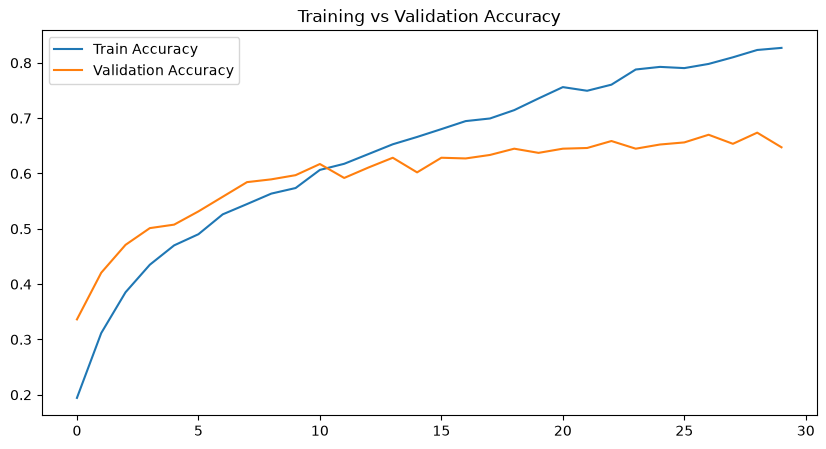

In [14]:
#Train vs validation 
plt.figure(figsize=(10,5))

plt.plot(
    cnn.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    cnn.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.legend()

plt.title("Training vs Validation Accuracy")

plt.show()

In [15]:
# Data Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

model1.compile(optimizer=Adam(learning_rate=0.001),
               loss='categorical_crossentropy',
               metrics=['accuracy'])

cnn_aug = model1.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=30,
    validation_data=(X_test, y_test)
)

Epoch 1/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.4123 - loss: 1.9726 - val_accuracy: 0.5448 - val_loss: 1.5270
Epoch 2/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.4561 - loss: 1.7499 - val_accuracy: 0.5498 - val_loss: 1.4842
Epoch 3/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.4919 - loss: 1.6250 - val_accuracy: 0.5730 - val_loss: 1.3526
Epoch 4/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.5129 - loss: 1.5486 - val_accuracy: 0.5821 - val_loss: 1.2901
Epoch 5/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.5328 - loss: 1.4731 - val_accuracy: 0.6143 - val_loss: 1.2243
Epoch 6/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.5454 - loss: 1.4361 - val_accuracy: 0.6123 - val_loss: 1.2157
Epoch 7/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.5600 - loss: 1.3845 - val_accuracy: 0.6153 - val_loss: 1.1912
Epoch 8/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.5673 - loss: 1.3318 - val_accu

In [16]:
best_epoch_idx = np.argmax(cnn_aug.history['val_accuracy'])

best_epoch = best_epoch_idx + 1

best_train_acc = cnn_aug.history['accuracy'][best_epoch_idx]
best_val_acc = cnn_aug.history['val_accuracy'][best_epoch_idx]

best_train_loss = cnn_aug.history['loss'][best_epoch_idx]
best_val_loss = cnn_aug.history['val_loss'][best_epoch_idx]

print("Best Epoch:", best_epoch)
print("Train Accuracy:", best_train_acc)
print("Validation Accuracy:", best_val_acc)
print("Train Loss:", best_train_loss)
print("Validation Loss:", best_val_loss)

df_cnn_aug = pd.DataFrame({
    'Model': ['CNN With Data Augmentation'],
    'Epoch': [best_epoch],
    'Training Accuracy': [best_train_acc],
    'Validation Accuracy': [best_val_acc],
    'Training Loss': [best_train_loss],
    'Validation Loss': [best_val_loss]
})

df_model = pd.concat([df_model, df_cnn_aug], ignore_index=True)

Best Epoch: 30
Train Accuracy: 0.7001007795333862
Validation Accuracy: 0.6968781352043152
Train Loss: 0.8879575133323669
Validation Loss: 0.9979956746101379


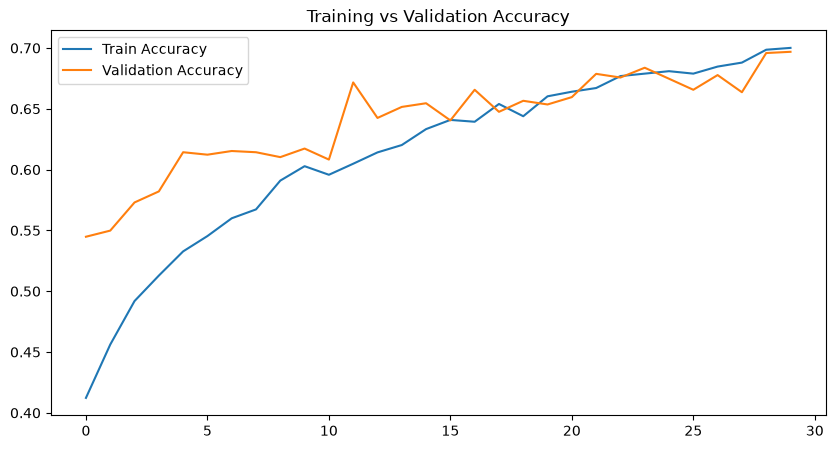

In [17]:
#Train vs validation 
plt.figure(figsize=(10,5))

plt.plot(
    cnn_aug.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    cnn_aug.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.legend()

plt.title("Training vs Validation Accuracy")

plt.show()

In [18]:
# early stopping

from tensorflow.keras.callbacks import EarlyStopping

#Train CNN
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_custom_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="min",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.2,
    patience=10,
    verbose=1
)

model1.compile(optimizer=Adam(learning_rate=0.001),
               loss='categorical_crossentropy',
               metrics=['accuracy'])

tuned_cnn = model1.fit(
    X_train, y_train,
    epochs=30,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/30
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7683 - loss: 0.6761
Epoch 1: val_accuracy improved from None to 0.84257, saving model to best_custom_cnn.keras

Epoch 1: finished saving model to best_custom_cnn.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.7678 - loss: 0.6773 - val_accuracy: 0.8426 - val_loss: 0.4631 - learning_rate: 0.0010
Epoch 2/30
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8166 - loss: 0.5258
Epoch 2: val_accuracy did not improve from 0.84257
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.8166 - loss: 0.5256 - val_accuracy: 0.8426 - val_loss: 0.4517 - learning_rate: 0.0010
Epoch 3/30
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8513 - loss: 0.4161
Epoch 3: val_accuracy improved from 0.84257 to 0.83753, saving model to best_custom_cnn.keras

Epoch 3: finished saving model to best_custom_cnn.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.8513 - loss: 0.4163 - val_accuracy: 0.8375 - val_

In [19]:
best_epoch_idx = np.argmax(tuned_cnn.history['val_accuracy'])

best_epoch = best_epoch_idx + 1

best_train_acc = tuned_cnn.history['accuracy'][best_epoch_idx]
best_val_acc = tuned_cnn.history['val_accuracy'][best_epoch_idx]

best_train_loss = tuned_cnn.history['loss'][best_epoch_idx]
best_val_loss = tuned_cnn.history['val_loss'][best_epoch_idx]

print("Best Epoch:", best_epoch)
print("Train Accuracy:", best_train_acc)
print("Validation Accuracy:", best_val_acc)
print("Train Loss:", best_train_loss)
print("Validation Loss:", best_val_loss)

df_tuned_cnn = pd.DataFrame({
    'Model': ['Tuned CNN'],
    'Epoch': [best_epoch],
    'Training Accuracy': [best_train_acc],
    'Validation Accuracy': [best_val_acc],
    'Training Loss': [best_train_loss],
    'Validation Loss': [best_val_loss]
})

df_model = pd.concat([df_model, df_tuned_cnn], ignore_index=True)

Best Epoch: 1
Train Accuracy: 0.7678008675575256
Validation Accuracy: 0.8425692915916443
Train Loss: 0.677284300327301
Validation Loss: 0.4631327688694


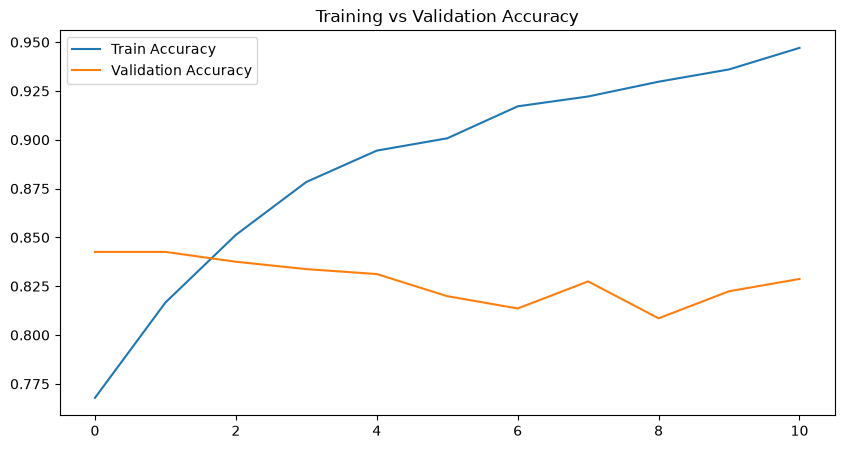

In [20]:
#Train vs validation 
plt.figure(figsize=(10,5))

plt.plot(
    tuned_cnn.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    tuned_cnn.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.legend()

plt.title("Training vs Validation Accuracy")

plt.show()

In [21]:
# pre trained model - VGG16

from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from torchgen import model

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = True

# Freeze initial layers
for layer in base_model.layers[:-4]:
    layer.trainable = False

model2 = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(le.classes_), activation='softmax')
])

from tensorflow.keras.optimizers import Adam

model2.compile(
    optimizer=Adam(learning_rate=0.0001),  # smaller Learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

vgg16 = model2.fit(
    X_train, y_train,
    epochs=30,
    validation_data=(X_test, y_test)
)

Epoch 1/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 48s 384ms/step - accuracy: 0.5537 - loss: 1.4761 - val_accuracy: 0.7150 - val_loss: 0.9375
Epoch 2/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 52s 420ms/step - accuracy: 0.7336 - loss: 0.8515 - val_accuracy: 0.7613 - val_loss: 0.7313
Epoch 3/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 53s 425ms/step - accuracy: 0.8070 - loss: 0.6158 - val_accuracy: 0.7986 - val_loss: 0.6452
Epoch 4/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 53s 430ms/step - accuracy: 0.8730 - loss: 0.3999 - val_accuracy: 0.7946 - val_loss: 0.6581
Epoch 5/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 53s 426ms/step - accuracy: 0.8982 - loss: 0.3213 - val_accuracy: 0.8006 - val_loss: 0.6745
Epoch 6/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 52s 424ms/step - accuracy: 0.9340 - loss: 0.2151 - val_accuracy: 0.8197 - val_loss: 0.6702
Epoch 7/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 52s 419ms/step - accuracy: 0.9526 - loss: 0.1498 - val_accuracy: 0.8167 - val_loss: 0.7064
Epoch 8/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 53s 427ms/step - accuracy: 0.9632 - loss: 0

In [22]:
best_epoch_idx = np.argmax(vgg16.history['val_accuracy'])

best_epoch = best_epoch_idx + 1

best_train_acc = vgg16.history['accuracy'][best_epoch_idx]
best_val_acc = vgg16.history['val_accuracy'][best_epoch_idx]

best_train_loss = vgg16.history['loss'][best_epoch_idx]
best_val_loss = vgg16.history['val_loss'][best_epoch_idx]

print("Best Epoch:", best_epoch)
print("Train Accuracy:", best_train_acc)
print("Validation Accuracy:", best_val_acc)
print("Train Loss:", best_train_loss)
print("Validation Loss:", best_val_loss)

df_vgg16 = pd.DataFrame({
    'Model': ['VGG16'],
    'Epoch': [best_epoch],
    'Training Accuracy': [best_train_acc],
    'Validation Accuracy': [best_val_acc],
    'Training Loss': [best_train_loss],
    'Validation Loss': [best_val_loss]
})

df_model = pd.concat([df_model, df_vgg16], ignore_index=True)

Best Epoch: 23
Train Accuracy: 0.9924395084381104
Validation Accuracy: 0.8338368535041809
Train Loss: 0.028171619400382042
Validation Loss: 0.9684262871742249


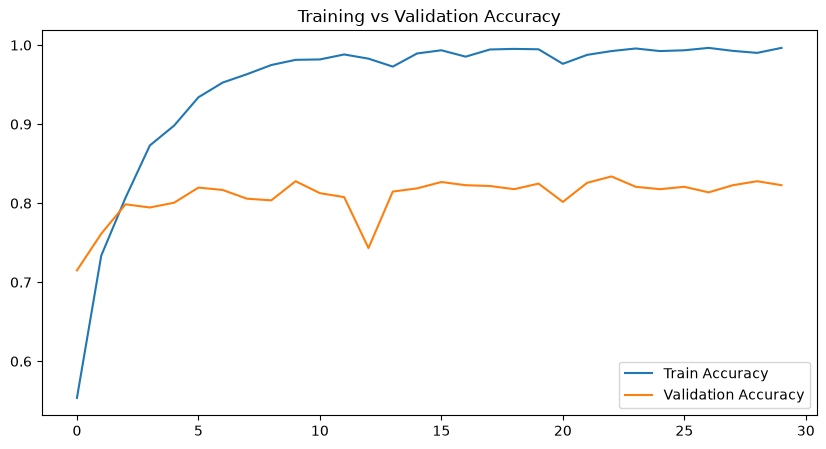

In [23]:
#Train vs validation 
plt.figure(figsize=(10,5))

plt.plot(
    vgg16.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    vgg16.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.legend()

plt.title("Training vs Validation Accuracy")

plt.show()

In [24]:
# Tuned VGG16

import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

# Fine-tuning: freeze most layers
for layer in base_model.layers[:-6]:
    layer.trainable = False

for layer in base_model.layers[-6:]:
    layer.trainable = True

# load Vgg16 base model
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

# Build model
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.6)(x)
output = layers.Dense(len(le.classes_), activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Call backs
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(patience=3, factor=0.3)
model_checkpoint = ModelCheckpoint('best_tuned_vgg16.keras', save_best_only=True, monitor='val_accuracy', mode='max')

# Train model
tuned_vgg16 = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=30,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr, model_checkpoint]
)

Epoch 1/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 117s 930ms/step - accuracy: 0.2772 - loss: 2.3214 - val_accuracy: 0.4592 - val_loss: 2.0279 - learning_rate: 1.0000e-04
Epoch 2/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 120s 972ms/step - accuracy: 0.4851 - loss: 1.7433 - val_accuracy: 0.4894 - val_loss: 1.7566 - learning_rate: 1.0000e-04
Epoch 3/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 120s 967ms/step - accuracy: 0.5801 - loss: 1.4250 - val_accuracy: 0.6022 - val_loss: 1.4856 - learning_rate: 1.0000e-04
Epoch 4/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 119s 964ms/step - accuracy: 0.6489 - loss: 1.1745 - val_accuracy: 0.6153 - val_loss: 1.1686 - learning_rate: 1.0000e-04
Epoch 5/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 119s 964ms/step - accuracy: 0.6840 - loss: 1.0251 - val_accuracy: 0.6455 - val_loss: 1.1302 - learning_rate: 1.0000e-04
Epoch 6/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 121s 977ms/step - accuracy: 0.7308 - loss: 0.8824 - val_accuracy: 0.7724 - val_loss: 0.7767 - learning_rate: 1.0000e-04
Epoch 7/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 

In [25]:
best_epoch_idx = np.argmax(tuned_vgg16.history['val_accuracy'])

best_epoch = best_epoch_idx + 1

best_train_acc = tuned_vgg16.history['accuracy'][best_epoch_idx]
best_val_acc = tuned_vgg16.history['val_accuracy'][best_epoch_idx]

best_train_loss = tuned_vgg16.history['loss'][best_epoch_idx]
best_val_loss = tuned_vgg16.history['val_loss'][best_epoch_idx]

print("Best Epoch:", best_epoch)
print("Train Accuracy:", best_train_acc)
print("Validation Accuracy:", best_val_acc)
print("Train Loss:", best_train_loss)
print("Validation Loss:", best_val_loss)

df_tuned_vgg16 = pd.DataFrame({
    'Model': ['Tuned VGG16'],
    'Epoch': [best_epoch],
    'Training Accuracy': [best_train_acc],
    'Validation Accuracy': [best_val_acc],
    'Training Loss': [best_train_loss],
    'Validation Loss': [best_val_loss]
})

df_model = pd.concat([df_model, df_tuned_vgg16], ignore_index=True)

Best Epoch: 20
Train Accuracy: 0.9558971524238586
Validation Accuracy: 0.862034261226654
Train Loss: 0.16331590712070465
Validation Loss: 0.5124195218086243


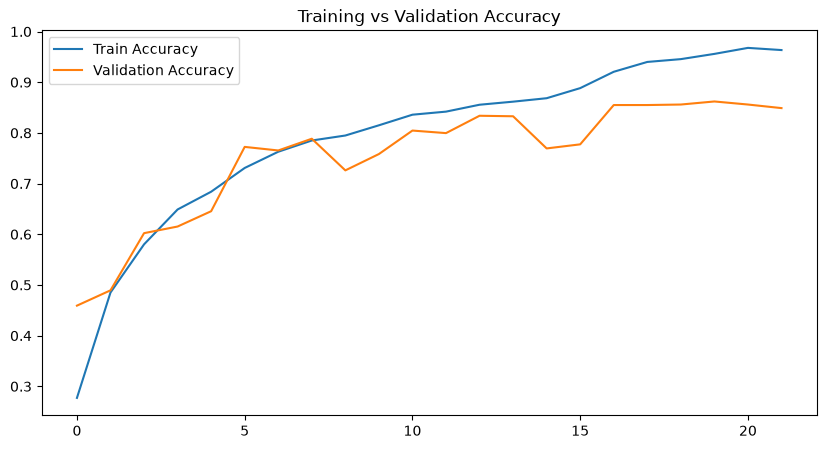

In [26]:
#Train vs validation 
plt.figure(figsize=(10,5))

plt.plot(
    tuned_vgg16.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    tuned_vgg16.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.legend()

plt.title("Training vs Validation Accuracy")

plt.show()

In [27]:
from tensorflow.keras.applications import ResNet50

#Resnet 50
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(
    len(le.classes_),
    activation='softmax'
)(x)

model = models.Model(
    inputs=base_model.input,
    outputs=output
)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Call backs
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(patience=3, factor=0.3)
model_checkpoint = ModelCheckpoint('best_tuned_resnet50.keras', save_best_only=True, monitor='val_accuracy', mode='max')

resnet = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=30,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr, model_checkpoint]
)

Epoch 1/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 88s 590ms/step - accuracy: 0.5076 - loss: 1.6588 - val_accuracy: 0.0977 - val_loss: 3.0663 - learning_rate: 1.0000e-04
Epoch 2/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 74s 595ms/step - accuracy: 0.7495 - loss: 0.7911 - val_accuracy: 0.0282 - val_loss: 2.9697 - learning_rate: 1.0000e-04
Epoch 3/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 74s 596ms/step - accuracy: 0.8241 - loss: 0.5377 - val_accuracy: 0.0504 - val_loss: 3.1863 - learning_rate: 1.0000e-04
Epoch 4/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 73s 589ms/step - accuracy: 0.8662 - loss: 0.4015 - val_accuracy: 0.0755 - val_loss: 3.0972 - learning_rate: 1.0000e-04
Epoch 5/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 73s 592ms/step - accuracy: 0.8899 - loss: 0.3236 - val_accuracy: 0.3505 - val_loss: 2.3770 - learning_rate: 1.0000e-04
Epoch 6/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 76s 616ms/step - accuracy: 0.9131 - loss: 0.2596 - val_accuracy: 0.6556 - val_loss: 1.2488 - learning_rate: 1.0000e-04
Epoch 7/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 74s 59

In [28]:
best_epoch_idx = np.argmax(resnet.history['val_accuracy'])

best_epoch = best_epoch_idx + 1

best_train_acc = resnet.history['accuracy'][best_epoch_idx]
best_val_acc = resnet.history['val_accuracy'][best_epoch_idx]

best_train_loss = resnet.history['loss'][best_epoch_idx]
best_val_loss = resnet.history['val_loss'][best_epoch_idx]

print("Best Epoch:", best_epoch)
print("Train Accuracy:", best_train_acc)
print("Validation Accuracy:", best_val_acc)
print("Train Loss:", best_train_loss)
print("Validation Loss:", best_val_loss)

df_tuned_resnet = pd.DataFrame({
    'Model': ['Tuned ResNet50'],
    'Epoch': [best_epoch],
    'Training Accuracy': [best_train_acc],
    'Validation Accuracy': [best_val_acc],
    'Training Loss': [best_train_loss],
    'Validation Loss': [best_val_loss]
})

df_model = pd.concat([df_model, df_tuned_resnet], ignore_index=True)

Best Epoch: 16
Train Accuracy: 0.9891632795333862
Validation Accuracy: 0.8529707789421082
Train Loss: 0.03365633636713028
Validation Loss: 0.6923688650131226


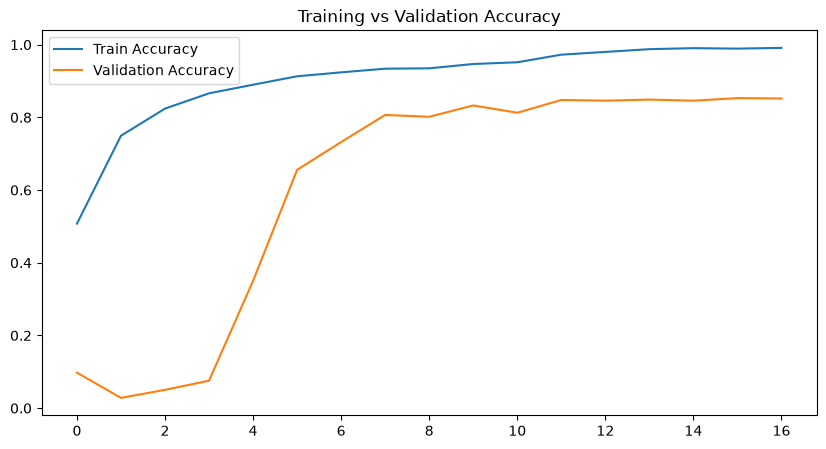

In [29]:
#Train vs validation 
plt.figure(figsize=(10,5))

plt.plot(
    resnet.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    resnet.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.legend()

plt.title("Training vs Validation Accuracy")

plt.show()

In [30]:
from tensorflow.keras.applications import EfficientNetB0
#eff 50
eff_base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

x = eff_base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(
    len(le.classes_),
    activation='softmax'
)(x)

model = models.Model(
    inputs=eff_base.input,
    outputs=output
)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Call backs
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(patience=3, factor=0.3)
model_checkpoint = ModelCheckpoint('best_tuned_effnetb0.keras', save_best_only=True, monitor='val_accuracy', mode='max')

effnet = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=30,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr, model_checkpoint]
)

Epoch 1/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 57s 331ms/step - accuracy: 0.3508 - loss: 2.0761 - val_accuracy: 0.0614 - val_loss: 2.7422 - learning_rate: 1.0000e-04
Epoch 2/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 42s 339ms/step - accuracy: 0.5761 - loss: 1.3608 - val_accuracy: 0.1198 - val_loss: 2.5498 - learning_rate: 1.0000e-04
Epoch 3/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 42s 339ms/step - accuracy: 0.6822 - loss: 1.0414 - val_accuracy: 0.3565 - val_loss: 2.0305 - learning_rate: 1.0000e-04
Epoch 4/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 42s 342ms/step - accuracy: 0.7356 - loss: 0.8147 - val_accuracy: 0.4955 - val_loss: 1.6639 - learning_rate: 1.0000e-04
Epoch 5/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 43s 346ms/step - accuracy: 0.7858 - loss: 0.6719 - val_accuracy: 0.6667 - val_loss: 1.0647 - learning_rate: 1.0000e-04
Epoch 6/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 44s 354ms/step - accuracy: 0.8085 - loss: 0.5876 - val_accuracy: 0.7221 - val_loss: 0.8331 - learning_rate: 1.0000e-04
Epoch 7/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 42s 33

In [31]:
best_epoch_idx = np.argmax(effnet.history['val_accuracy'])

best_epoch = best_epoch_idx + 1

best_train_acc = effnet.history['accuracy'][best_epoch_idx]
best_val_acc = effnet.history['val_accuracy'][best_epoch_idx]

best_train_loss = effnet.history['loss'][best_epoch_idx]
best_val_loss = effnet.history['val_loss'][best_epoch_idx]

print("Best Epoch:", best_epoch)
print("Train Accuracy:", best_train_acc)
print("Validation Accuracy:", best_val_acc)
print("Train Loss:", best_train_loss)
print("Validation Loss:", best_val_loss)

df_tuned_effnet = pd.DataFrame({
    'Model': ['Tuned EfficientNetB0'],
    'Epoch': [best_epoch],
    'Training Accuracy': [best_train_acc],
    'Validation Accuracy': [best_val_acc],
    'Training Loss': [best_train_loss],
    'Validation Loss': [best_val_loss]
})

df_model = pd.concat([df_model, df_tuned_effnet], ignore_index=True)

Best Epoch: 21
Train Accuracy: 0.9216229915618896
Validation Accuracy: 0.8358509540557861
Train Loss: 0.23791691660881042
Validation Loss: 0.5013571977615356


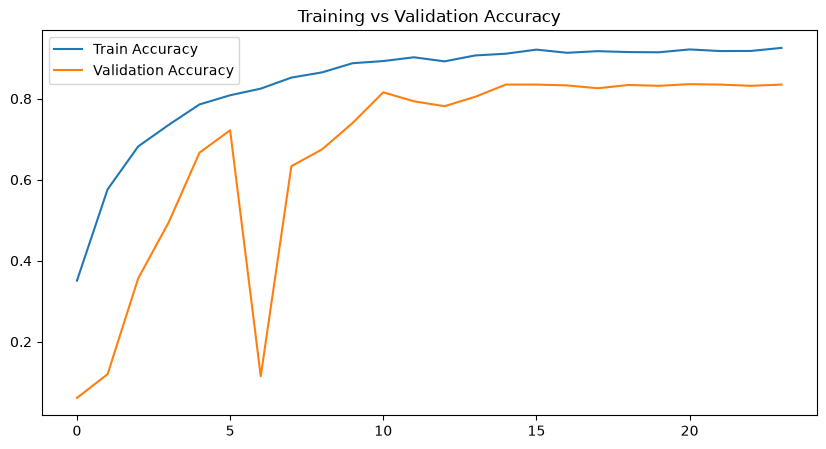

In [32]:
#Train vs validation 
plt.figure(figsize=(10,5))

plt.plot(
    effnet.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    effnet.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.legend()

plt.title("Training vs Validation Accuracy")

plt.show()

In [34]:
# Rank models by their best validation accuracy
model_ranking = (
    df_model.sort_values("Validation Accuracy", ascending=False)
)

display(model_ranking)

# The current `model` is the tuned VGG16 model
best_model = model

print("Best model:", model_ranking.iloc[0]["Model"])
print("\nModel summary:")
best_model.summary(expand_nested=True, show_trainable=True)

# Print layers in descending order
print("\nLayers in descending order:")
for index, layer in reversed(list(enumerate(best_model.layers))):
    print(f"{index}: {layer.name} ({layer.__class__.__name__})")


,Model,Epoch,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss
4,Tuned VGG16,20,0.955897,0.862034,0.163316,0.512420
5,Tuned ResNet50,16,0.989163,0.852971,0.033656,0.692369
2,Tuned CNN,1,0.767801,0.842569,0.677284,0.463133
6,Tuned EfficientNetB0,21,0.921623,0.835851,0.237917,0.501357
3,VGG16,23,0.992440,0.833837,0.028172,0.968426
1,CNN With Data Augmentation,30,0.700101,0.696878,0.887958,0.997996
0,Basic CNN,29,0.823251,0.673804,0.533811,1.244577


Best model: Tuned VGG16

Model summary:


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_6     │ (None, 128,     │         0 │ -              │   -   │
│ (InputLayer)      │ 128, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling_2       │ (None, 128,     │         0 │ input_layer_6… │   -   │
│ (Rescaling)       │ 128, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ normalization_1   │ (None, 128,     │         7 │ rescaling_2[0… │   Y   │
│ (Normalization)   │ 128, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling_3       │ (None, 128,     │         0 │ normalization… │   -   │
│ (Rescaling)       │ 128, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ stem_conv_pad     │ (None, 129,     │         0 │ rescaling_3[0… │   -   │
│ (ZeroPadding2D)   │ 129, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ stem_conv         │ (None, 64, 64,  │     1,728 │ stem_conv_pad… │   Y   │
│ (Conv2D)          │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ stem_bn           │ (None, 64, 64,  │       256 │ stem_conv[0][… │   Y   │
│ (BatchNormalizat… │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ stem_activation   │ (None, 64, 64,  │         0 │ stem_bn[0][0]  │   -   │
│ (Activation)      │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_dwconv    │ (None, 64, 64,  │       576 │ stem_activati… │   Y   │
│ (DepthwiseConv2D) │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_bn        │ (None, 64, 64,  │       256 │ block1a_dwcon… │   Y   │
│ (BatchNormalizat… │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_activati… │ (None, 64, 64,  │         0 │ block1a_bn[0]… │   -   │
│ (Activation)      │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_se_squee… │ (None, 64)      │         0 │ block1a_activ… │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_se_resha… │ (None, 1, 1,    │         0 │ block1a_se_sq… │   -   │
│ (Reshape)         │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_se_reduce │ (None, 1, 1,    │     1,040 │ block1a_se_re… │   Y   │
│ (Conv2D)          │ 16)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_se_expand │ (None, 1, 1,    │     1,088 │ block1a_se_re… │   Y   │
│ (Conv2D)          │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_se_excite │ (None, 64, 64,  │         0 │ block1a_activ… │   -   │
│ (Multiply)        │ 64)             │           │ block1a_se_ex… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_project_… │ (None, 64, 64,  │     2,048 │ block1a_se_ex… │   Y 

 Total params: 192,660,451 (734.94 MB)

 Trainable params: 64,116,574 (244.59 MB)

 Non-trainable params: 310,727 (1.19 MB)

 Optimizer params: 128,233,150 (489.17 MB)


Layers in descending order:
817: dense_11 (Dense)
816: dropout_5 (Dropout)
815: dense_10 (Dense)
814: global_average_pooling2d_3 (GlobalAveragePooling2D)
813: top_activation (Activation)
812: top_bn (BatchNormalization)
811: top_conv (Conv2D)
810: block7d_add (Add)
809: block7d_drop (Dropout)
808: block7d_project_bn (BatchNormalization)
807: block7d_project_conv (Conv2D)
806: block7d_se_excite (Multiply)
805: block7d_se_expand (Conv2D)
804: block7d_se_reduce (Conv2D)
803: block7d_se_reshape (Reshape)
802: block7d_se_squeeze (GlobalAveragePooling2D)
801: block7d_activation (Activation)
800: block7d_bn (BatchNormalization)
799: block7d_dwconv (DepthwiseConv2D)
798: block7d_expand_activation (Activation)
797: block7d_expand_bn (BatchNormalization)
796: block7d_expand_conv (Conv2D)
795: block7c_add (Add)
794: block7c_drop (Dropout)
793: block7c_project_bn (BatchNormalization)
792: block7c_project_conv (Conv2D)
791: block7c_se_excite (Multiply)
790: block7c_se_expand (Conv2D)
789: block7c_

In [35]:
from tensorflow.keras.models import load_model

model = load_model("best_tuned_vgg16.keras")

In [36]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "./sun-hat-with-a-wide-brim-elegant-beige-detailed-texture-isolated-on-a-white-background-format-for-fashion-and-retail-free-photo.jpg"  # change this

img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)

img_array = img_array / 255.0   # normalize
img_array = np.expand_dims(img_array, axis=0)  # shape (1,128,128,3)

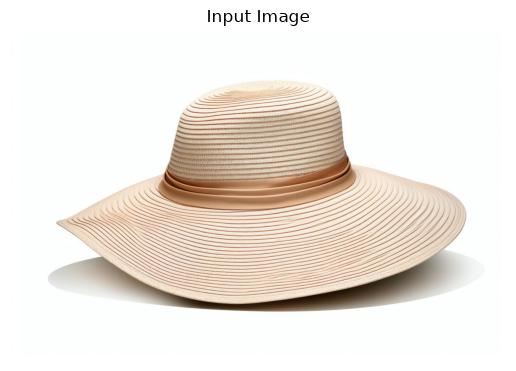

In [37]:
# Show image
import matplotlib.pyplot as plt

img = image.load_img(img_path)
plt.imshow(img)
plt.axis('off')
plt.title("Input Image")
plt.show()

In [40]:
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

print("Predicted class index:", predicted_class)

predicted_label = le.inverse_transform([predicted_class])
print("Predicted label:", predicted_label[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Predicted class index: 2
Predicted label: Hat


Test Loss: 0.5124
Test Accuracy: 0.8620



,precision,recall,f1-score,support
Blazer,0.578947,0.500000,0.536585,22.000000
Dress,0.772152,0.859155,0.813333,71.000000
Hat,0.971429,1.000000,0.985507,34.000000
Hoodie,0.500000,0.400000,0.444444,20.000000
Longsleeve,0.804196,0.821429,0.812721,140.000000
Outwear,0.718310,0.822581,0.766917,62.000000
Pants,0.944056,0.971223,0.957447,139.000000
Polo,0.666667,0.833333,0.740741,24.000000
Shirt,0.880597,0.776316,0.825175,76.000000
Shoes,0.976744,0.976744,0.976744,86.000000


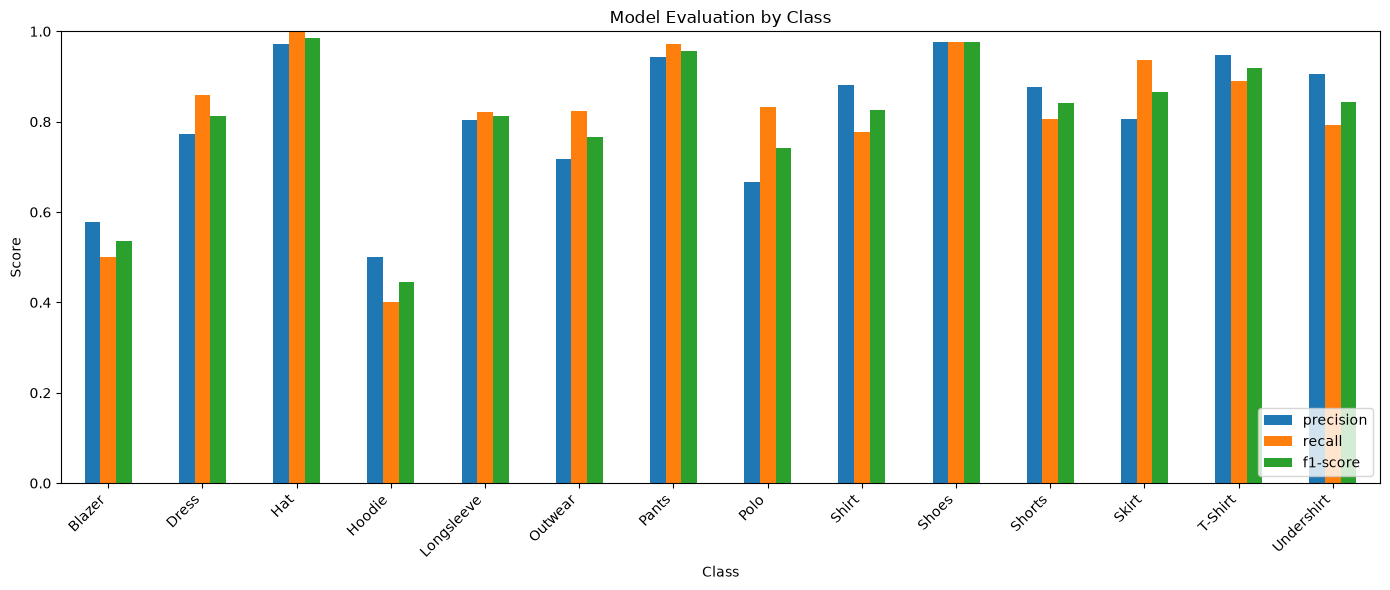

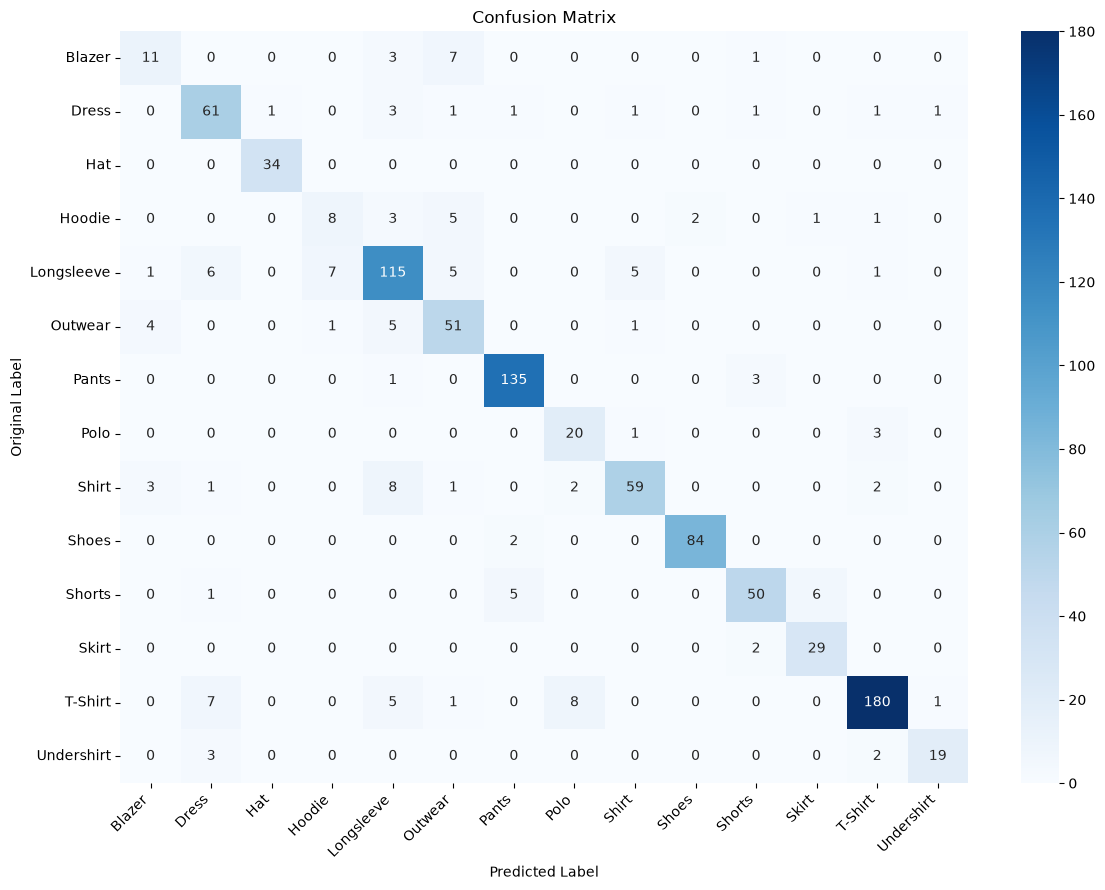

,Original Label,Predicted Label
0,Hoodie,Hoodie
1,Skirt,Skirt
2,Shirt,Longsleeve
3,Outwear,Blazer
4,T-Shirt,Polo
5,Shorts,Skirt
6,Shorts,Shorts
7,Longsleeve,Longsleeve
8,Pants,Pants
9,Shorts,Shorts


In [41]:

y_true = np.argmax(y_test, axis=1)

# Generate predictions
y_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# Overall evaluation
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}\n")

# Classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=le.classes_,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()
display(report_df)

# Precision, recall, and F1-score chart
metrics_df = report_df.loc[le.classes_, ["precision", "recall", "f1-score"]]

metrics_df.plot(kind="bar", figsize=(14, 6))
plt.title("Model Evaluation by Class")
plt.xlabel("Class")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Original Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Original versus predicted labels for the first test samples
comparison_df = pd.DataFrame({
    "Original Label": le.inverse_transform(y_true),
    "Predicted Label": le.inverse_transform(y_pred)
})

display(comparison_df.head(20))

In [ ]:
import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA Version:", torch.version.cuda)
    print("GPU Count:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("Current Device:", torch.cuda.current_device())
else:
    print("GPU not detected by PyTorch")

In [ ]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPUs:", tf.config.list_physical_devices('GPU'))